In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, f1_score , recall_score, confusion_matrix,precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import roc_curve, roc_auc_score

In [3]:
df = pd.read_csv("/content/loan_data.csv")
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


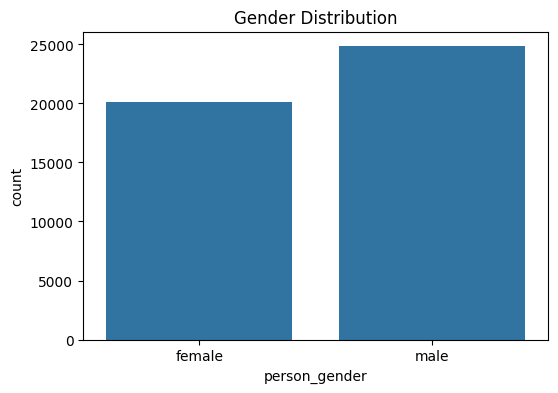

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="person_gender")

plt.title("Gender Distribution")
plt.show()

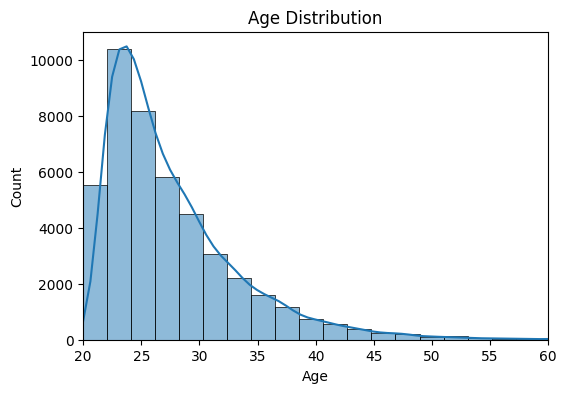

In [15]:
plt.figure(figsize=(6,4))

sns.histplot(df["person_age"], bins=60, kde=True)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.xlim(20, 60)

plt.show()

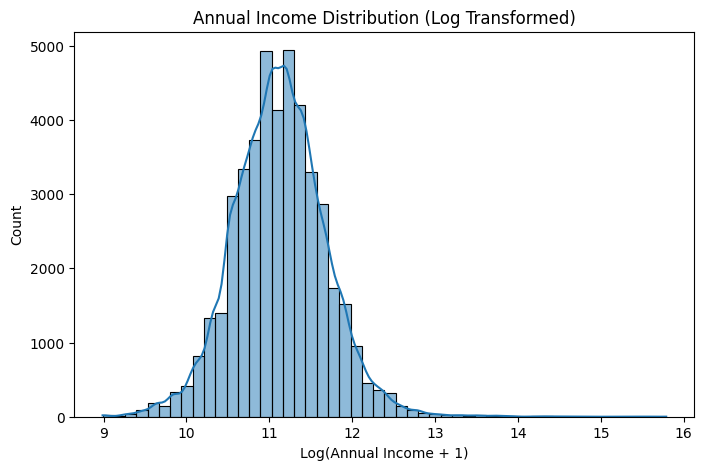

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(np.log1p(df["person_income"]), bins=50, kde=True)

plt.title("Annual Income Distribution (Log Transformed)")

plt.xlabel("Log(Annual Income + 1)")

plt.show()

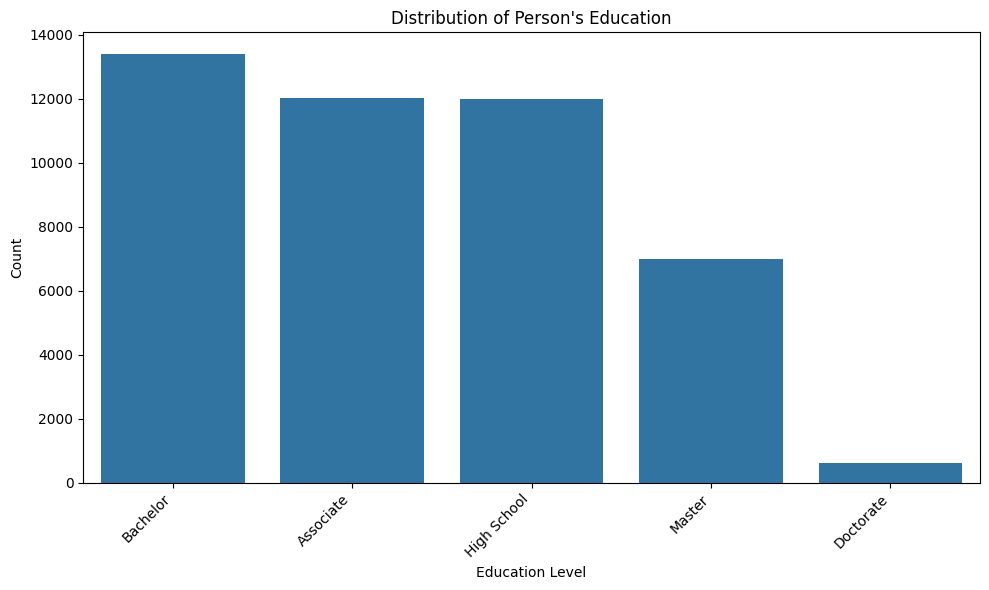

In [17]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="person_education", order=df["person_education"].value_counts().index)
plt.title("Distribution of Person's Education")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [18]:
import plotly.express as px

fig = px.box(df, y = "person_income", color = "person_gender",
             points = "all", notched = True,
             color_discrete_sequence = ["#0044FF", "#DE00FF"],
             title = "Male and Female Annual Income (k$)")

fig.update_traces(marker = dict(size = 5, symbol = "circle-open"))
fig.update_traces(fillcolor = "#000000")
fig.update_layout(template = "plotly_dark")

fig.show()

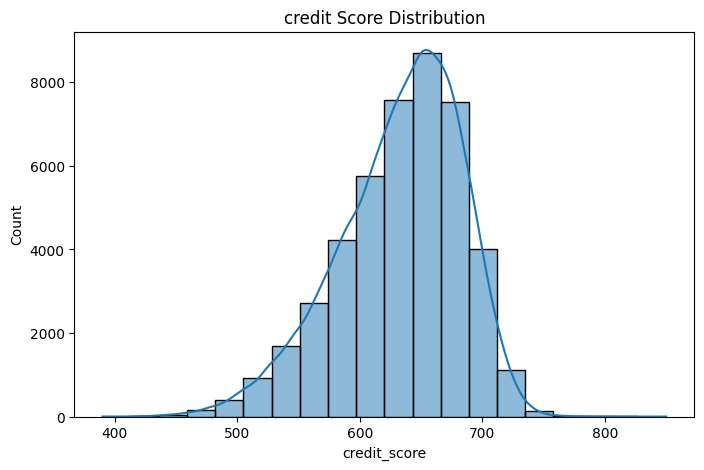

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df["credit_score"], bins=20, kde=True)

plt.title("credit Score Distribution")

plt.show()

In [4]:
# DATA PREPROCESSING
# 1. Missing Values Handling
missing_vals = df.isnull().sum()
if missing_vals.sum() > 0:
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)
        else:
            df[col].fillna(df[col].median(), inplace=True)

# 2. Feature and Target Separation
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# 3. Categorical Encoding
categorical_cols = X.select_dtypes(include=['object']).columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 4. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

# 5. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

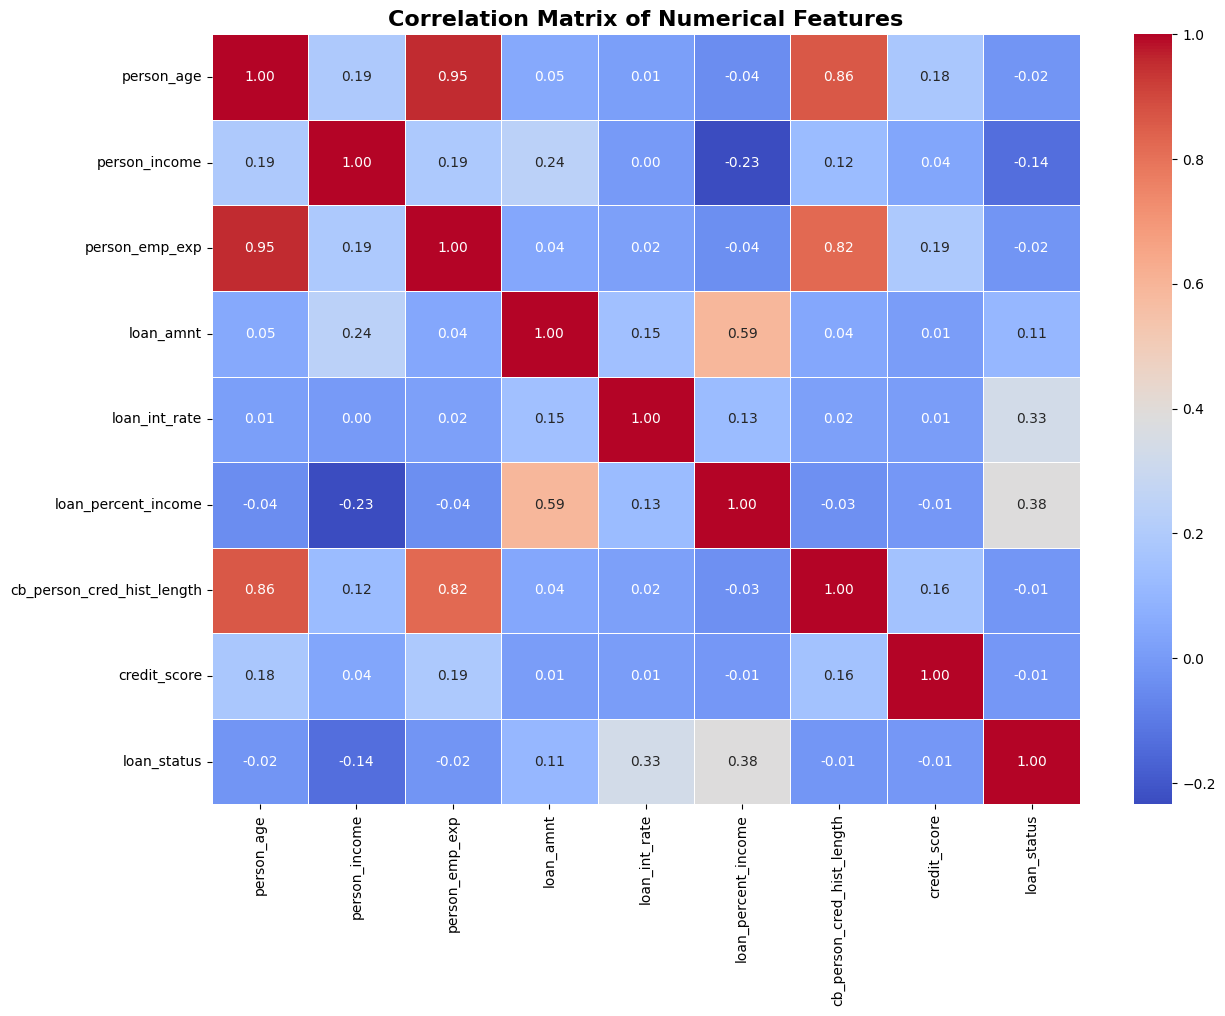

In [5]:
# Correlation Matrix
plt.figure(figsize=(14, 10))
num_df = df.select_dtypes(include=[np.number])
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold')
plt.show()

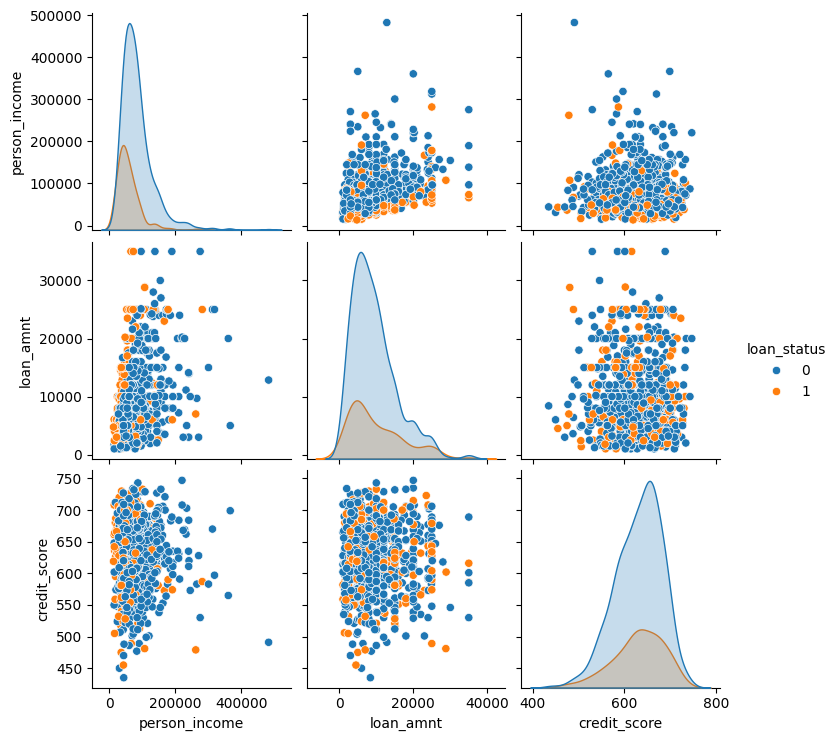

In [13]:
sns.pairplot(
    df.sample(1000, random_state=42),
    vars=[
        "person_income",
        "loan_amnt",
        "credit_score"
    ],
    hue="loan_status"
)

plt.show()

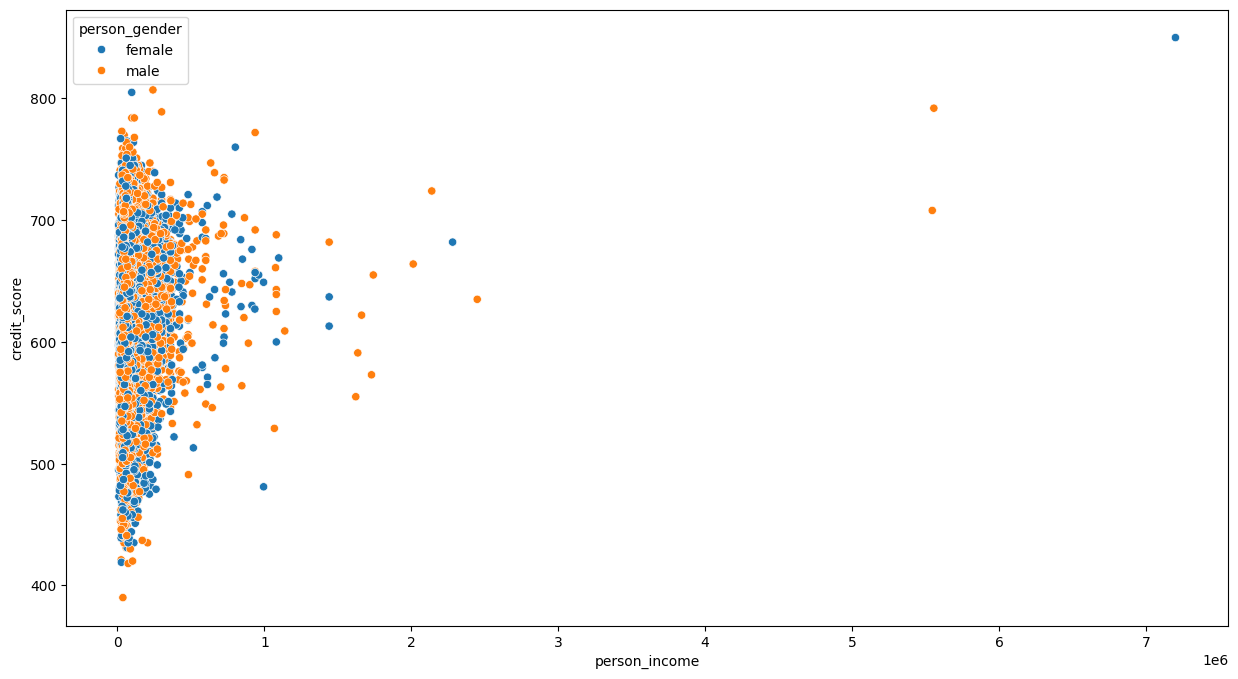

In [20]:
plt.figure(figsize=(15, 8))

sns.scatterplot(data=df, x='person_income', y='credit_score', hue='person_gender');

In [6]:
# Fit PCA
pca_full = PCA().fit(X_train_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

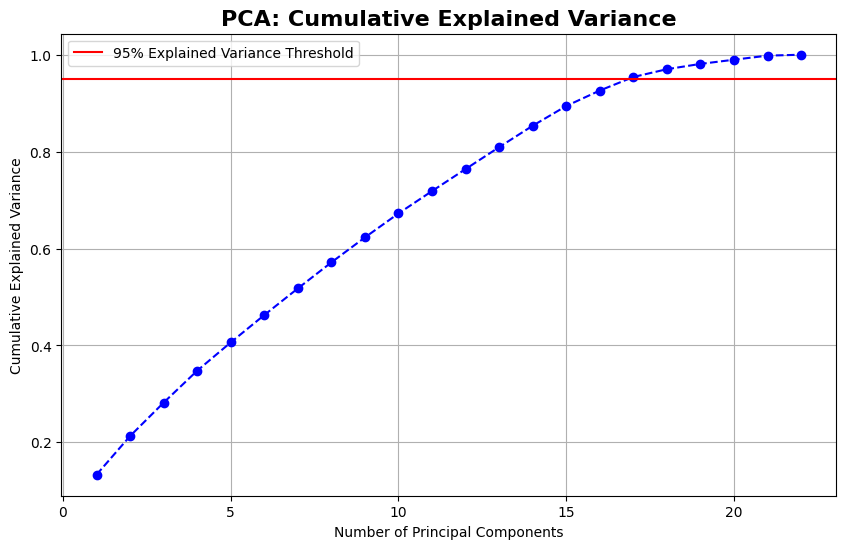

PCA transformation complete. Features reduced from 22 to 17 components.


In [7]:
# Explained Variance Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Explained Variance Threshold')
plt.title('PCA: Cumulative Explained Variance', fontsize=16, fontweight='bold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

# Transform data retaining 95% variance
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"PCA transformation complete. Features reduced from {X_train_scaled.shape[1]} to {X_train_pca.shape[1]} components.")

In [8]:
# MODEL TRAINING
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=42),
    "Support Vector Machine": SVC(probability=True, random_state=42)
}

results_no_pca = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    results_no_pca[name] = {'Accuracy': acc, 'F1_Score': f1, 'precision': pre, 'recall': recall}

    print(f"{name:25s} | Accuracy: {acc:.4f} | F1-Score: {f1:.4f} | recall: {recall:.4f} | precision:{pre:.4f}")

Logistic Regression       | Accuracy: 0.8998 | F1-Score: 0.7685 | recall: 0.7485 | precision:0.7896
Random Forest             | Accuracy: 0.9287 | F1-Score: 0.8273 | recall: 0.7690 | precision:0.8952


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [20:32:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost                   | Accuracy: 0.9372 | F1-Score: 0.8521 | recall: 0.8135 | precision:0.8944
Gradient Boosting         | Accuracy: 0.9231 | F1-Score: 0.8144 | recall: 0.7590 | precision:0.8785
K-Nearest Neighbors       | Accuracy: 0.8940 | F1-Score: 0.7468 | recall: 0.7035 | precision:0.7958
Decision Tree             | Accuracy: 0.8963 | F1-Score: 0.7355 | recall: 0.6485 | precision:0.8494
Support Vector Machine    | Accuracy: 0.9160 | F1-Score: 0.8000 | recall: 0.7560 | precision:0.8494


In [9]:
# WITH PCA
results_pca = {}
for name, model in models.items():
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    results_pca[name] = {'Accuracy': acc, 'F1_Score': f1, 'precision': pre, 'recall': recall}

    print(f"{name:25s} | Accuracy: {acc:.4f} | F1-Score: {f1:.4f} | recall: {recall:.4f} | precision:{pre:.4f}")


Logistic Regression       | Accuracy: 0.9003 | F1-Score: 0.7698 | recall: 0.7500 | precision:0.7907
Random Forest             | Accuracy: 0.9119 | F1-Score: 0.7884 | recall: 0.7385 | precision:0.8454


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [20:36:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost                   | Accuracy: 0.9089 | F1-Score: 0.7881 | recall: 0.7625 | precision:0.8155
Gradient Boosting         | Accuracy: 0.9052 | F1-Score: 0.7698 | recall: 0.7130 | precision:0.8364
K-Nearest Neighbors       | Accuracy: 0.8927 | F1-Score: 0.7442 | recall: 0.7025 | precision:0.7911
Decision Tree             | Accuracy: 0.8476 | F1-Score: 0.5809 | recall: 0.4755 | precision:0.7465
Support Vector Machine    | Accuracy: 0.9158 | F1-Score: 0.7996 | recall: 0.7560 | precision:0.8485


In [10]:
# RESULTS COMPARISON
model_names = list(models.keys())
acc_no_pca = [results_no_pca[m]['Accuracy'] for m in model_names]
acc_pca = [results_pca[m]['Accuracy'] for m in model_names]

fig = go.Figure()

fig.add_trace(go.Bar(
    x=model_names, y=acc_no_pca,
    name='Without PCA (Original Scaled)',
    marker_color='#2c3e50',
    text=[f"{val:.3f}" for val in acc_no_pca],
    textposition='auto'
))

fig.add_trace(go.Bar(
    x=model_names, y=acc_pca,
    name='With PCA (Reduced Dimensions)',
    marker_color='#e74c3c',
    text=[f"{val:.3f}" for val in acc_pca],
    textposition='auto'
))

fig.update_layout(
    title='Model Accuracy Comparison: Without PCA vs With PCA',
    xaxis_tickfont_size=14,
    yaxis=dict(title='Accuracy Score', titlefont_size=16, tickfont_size=14, range=[0, 1.1]),
    legend=dict(x=0.01, y=1.05, orientation="h"),
    barmode='group',
    bargap=0.15,
    bargroupgap=0.1,
    height=600
)

fig.show()


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning:

[20:40:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.




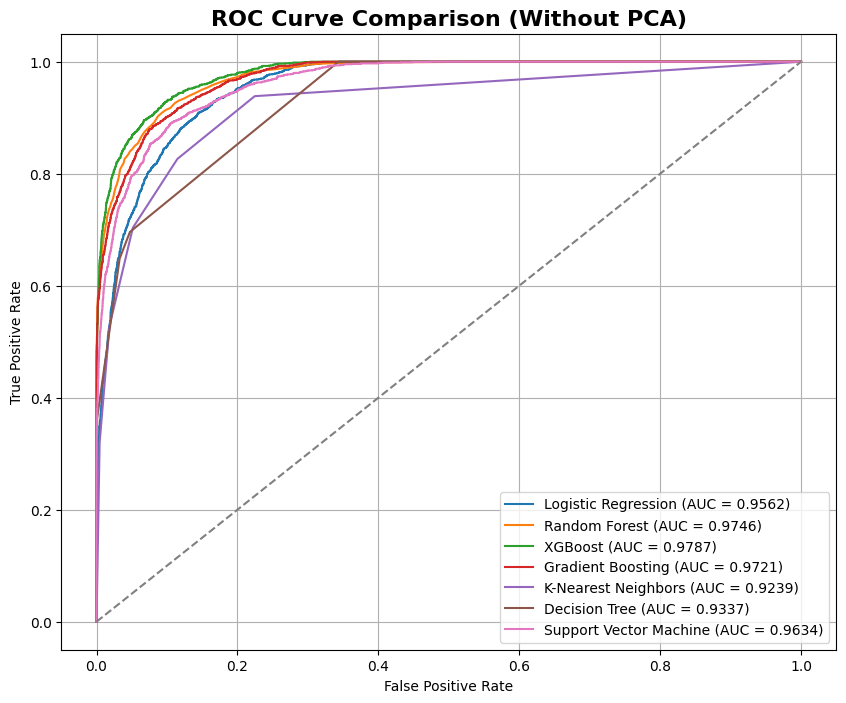

In [11]:
plt.figure(figsize=(10, 8))
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_probs = model.decision_function(X_test_scaled)
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc_score = roc_auc_score(y_test, y_probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (Without PCA)', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning:

[20:44:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.




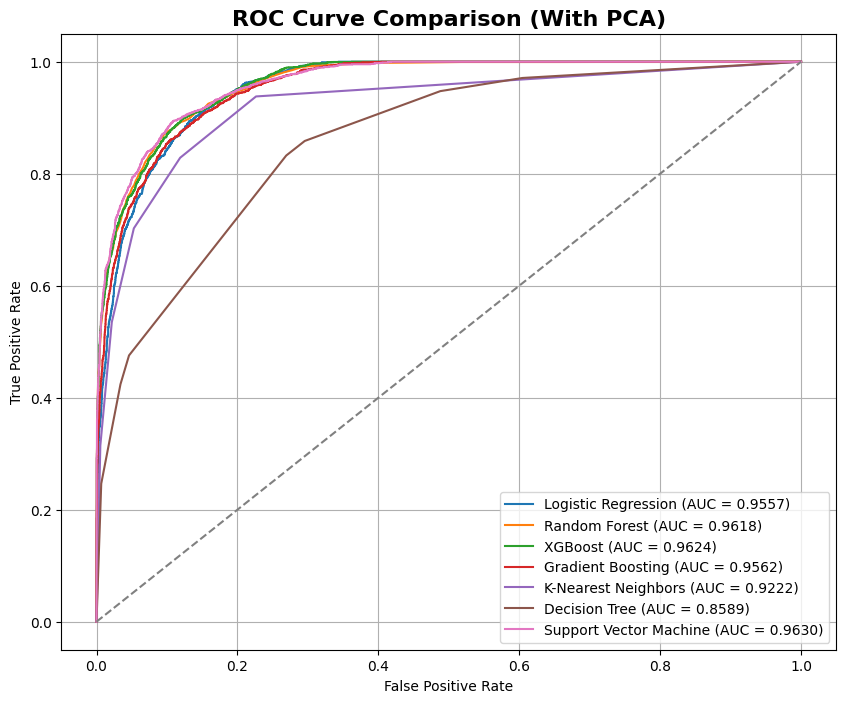

In [12]:
plt.figure(figsize=(10, 8))
for name, model in models.items():
    model.fit(X_train_pca, y_train)
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test_pca)[:, 1]
    else:
        y_probs = model.decision_function(X_test_pca)
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc_score = roc_auc_score(y_test, y_probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (With PCA)', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()